In [2]:
import json
from pathlib import Path
SCRIPT_DIR = Path.cwd()

try:
    from compression import zstd
except:
    from backports import zstd

import cv2
import einops
import mediapy
import numpy as np
import torch

from openpi.policies.libero_trace_dataset import LiberoTraceDataset
from openpi.training import config as _config

In [ ]:
from huggingface_hub import hf_hub_download
checkpoint_path = hf_hub_download(
    repo_id="facebook/jepa-wms",
    filename="dinov2_vits_224_INet.pth.tar"
)
checkpoint = torch.load(checkpoint_path, map_location="cuda:0")

In [ ]:
checkpoint['model']

In [3]:
out_dir = SCRIPT_DIR / "dino_outputs"

In [4]:
index = 0
with open(out_dir / f"{index}.meta.json", "r") as jf:
    shape, dtype = json.load(jf)
with zstd.open(out_dir / f"{index}.zstd", "rb") as zf:
    data = np.frombuffer(zf.read(), dtype=dtype).reshape(shape)

In [5]:
model, preprocessor = torch.hub.load(
    "facebookresearch/jepa-wms", "jepa_wm_pusht", device="cuda:0"
)

Using cache found in /u/jcpeng2/.cache/torch/hub/facebookresearch_jepa-wms_main
Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
Using cache found in /u/jcpeng2/.cache/torch/hub/facebookresearch_dinov2_main


In [12]:
results = model.decode_unroll(torch.tensor(einops.rearrange(data, "b t v h w c -> t b v h w c")).to("cuda:0"))

In [13]:
print(results.shape)

(292, 224, 224, 3)


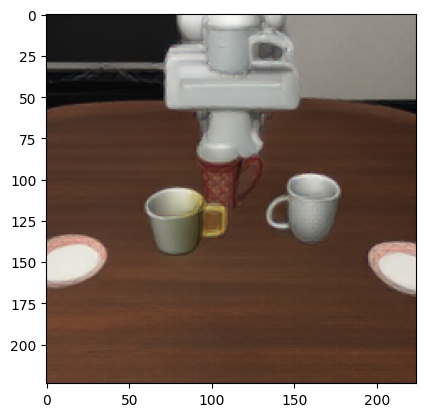

In [17]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.figure(0)
plt.clf()
plt.imshow(results[0])
plt.show()

In [6]:
data_config = _config.get_config('trace_vla_moe')
dataset = LiberoTraceDataset(data_config.data.base_config, data_config.model.action_horizon)

The dataset you requested (None) is in 2.0 format.
While current version of LeRobot is backward-compatible with it, the version of your dataset still uses global
stats instead of per-episode stats. Update your dataset stats to the new format using this command:
```
python lerobot/common/datasets/v21/convert_dataset_v20_to_v21.py --repo-id=None
```

If you encounter a problem, contact LeRobot maintainers on [Discord](https://discord.com/invite/s3KuuzsPFb)
or open an [issue on GitHub](https://github.com/huggingface/lerobot/issues/new/choose).



Resolving data files:   0%|          | 0/4338 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/163 [00:00<?, ?it/s]

Using LiberoTraceDataset (TraceVLA)


In [7]:
def get_episode(episode_idx):
    start_idx = dataset.episode_starts[episode_idx]
    end_idx = dataset.episode_ends[episode_idx]
    return dataset.hf_dataset[start_idx:end_idx]

In [7]:
%env LD_LIBRARY_PATH=/opt/nvidia/hpc_sdk/Linux_aarch64/25.5/cuda/12.9/lib64:$LD_LIBRARY_PATH
video = einops.rearrange(get_episode(index)['image'], "t c h w -> t h w c")
mediapy.write_video("out.mp4", video.cpu().numpy())

RuntimeError: Error writing 'out.mp4': /u/jcpeng2/.local/bin/ffmpeg: error while loading shared libraries: libcudart.so.12: cannot open shared object file: No such file or directory


In [ ]:
plt.figure(0)
plt.clf()
plt.imshow(einops.rearrange(video_data[0], "c h w -> h w c"))
plt.show()

In [52]:

# TODO: batch across episodes?
def batch_by_episode(samples_per_episode=10):
    N = len(dataset.episode_starts)
    for episode_index in torch.randperm(N):
        all_data = get_episode(episode_index)
        with open(out_dir / f"{episode_index}.meta.json", "r") as jf:
            shape, dtype = json.load(jf)
        with zstd.open(out_dir / f"{episode_index}.zstd", "rb") as zf:
            emb_data = np.frombuffer(zf.read(), dtype=dtype).reshape(shape)
        emb_data = einops.rearrange(emb_data, "1 t 1 h w c -> t h w c")
        ep_len = len(all_data)
        start_indices = torch.randint(ep_len-1, size=(samples_per_episode,))
        end_indices = start_indices + 1
        start_images = emb_data[start_indices]
        end_images = emb_data[end_indices]
        actions = np.array(all_data['actions'])[start_indices]
        yield (start_images, end_images, actions)

In [54]:
dset = batch_by_episode()
start, end, actions = next(dset)
print(start.shape, end.shape, actions.shape)

(10, 16, 16, 384) (10, 16, 16, 384) (10, 7)


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from modules import Transformer

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = Transformer(input_dim=384, hidden_dim=384, output_dim=384, depth=6, heads=16, dim_head=64, mlp_dim=2048, dropout=0.1)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

num_epochs = 1
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for starts, ends, actions in batch_by_episode():
        starts = torch.tensor(starts).to(device)
        ends = torch.tensor(ends).to(device)
        actions = torch.tensor(actions).to(device)

        optimizer.zero_grad()          # clear gradients
        outputs = model(inputs)        # forward pass
        loss = criterion(outputs, targets)
        loss.backward()                # backprop
        optimizer.step()               # update weights

        running_loss += loss.item() * inputs.size(0)

    epoch_loss = running_loss / len(loader.dataset)
    print(f"Epoch {epoch+1}/{num_epochs} — loss: {epoch_loss:.4f}")